In [7]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args
from itertools import product

In [8]:
import importlib
import superlets_package.morlet as morlet
import superlets_package.superlets as superlet
import jax.numpy as jnp

In [9]:
importlib.reload(morlet)
importlib.reload(superlet)

<module 'superlets_package.superlets' from '/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/superlets_package/superlets.py'>

In [10]:
# test_signal = np.load('/Users/neuralrehabilitationgroup/PycharmProjects/Superlets-Marina/RESULTS/signal_2.npy')
# plt.plot(test_signal)

In [11]:
fontsize_title = 10
fontsize_subtitle = 16
fontsize_ticks = 12
fontsize_labels = 14
fontsize_legend = 14

In [12]:
fs = 1024
signal_duration = 3
t = np.linspace(0, signal_duration, signal_duration * fs)

In [13]:
np.random.seed(10)
noise = np.random.normal(0, 0.01, len(t))

In [14]:
burst_duration = 0.5
burst_start = 1
real_t_onset = burst_start
real_t_offset = burst_start + burst_duration

In [15]:
start_idx = np.searchsorted(t, burst_start)  # Encuentra el índice de inicio
end_idx = np.searchsorted(t, burst_start + burst_duration)  # Encuentra el índice final

MNF ideal = 149.14318138165422
MNF analytic = 164.77343195705885


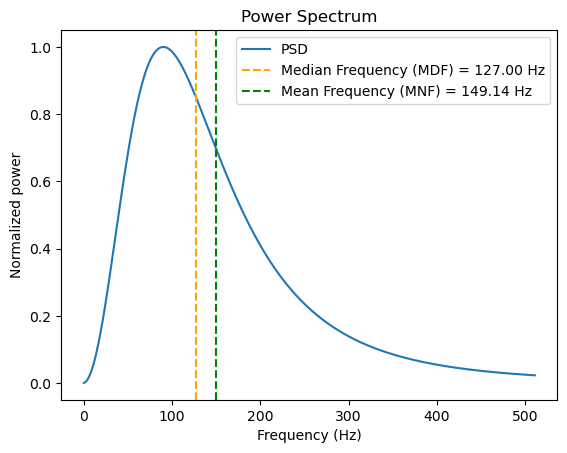

In [16]:
burst = []
[filtro, PdeLuca, burst, MNF_ideal, MNF_analytic] = superlet.fdeluca(140, 110, fs, burst_duration, plot = False)
print(f'MNF ideal = {MNF_ideal}')
print(f'MNF analytic = {MNF_analytic}')
MNF_1 = [MNF_ideal]

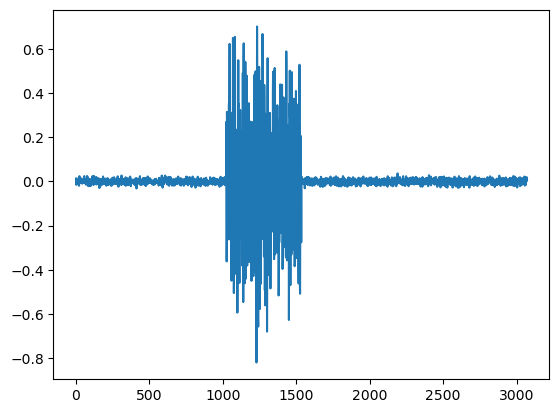

In [17]:
burst_signal = noise.copy()
burst_signal[int(burst_start * fs):int(burst_start * fs + len(burst))] = burst
plt.plot(burst_signal)

In [18]:
test_signal = burst_signal

In [19]:
freqs = np.linspace(10,500,int(fs/2))

In [20]:
nfft = 2 * (len(freqs))
ms_per_cycle = 12.67

In [21]:
def get_onset_offset(matrix, burst_start, burst_duration, t, Fs, plot_data=False, std_threshold=None):
    first_indices = []
    last_indices = []

    for row in matrix:
        first_idx, last_idx = superlet.find_plateau_region(
            row, burst_start, burst_duration, t, Fs,
            smooth_sigma=smooth_sigma, plot=plot, std_threshold=std_threshold
        )
        first_indices.append(first_idx)
        last_indices.append(last_idx)

    return t[first_indices], t[last_indices]

# DEFINICIÓN DEL ESPACIO DE LOS PARÁMETROS

In [22]:
smooth_sigma = 20
contamination = False

w_f = 0.005
w_t = 0.995
eps = 1e-12

# CWT


        OUR CWT → Barrido 1D parámetro c

Checking parameter c = 1
Checking parameter c = 11
Checking parameter c = 21
Checking parameter c = 31
Checking parameter c = 41
Checking parameter c = 51
Checking parameter c = 61
Checking parameter c = 71
Checking parameter c = 81
Checking parameter c = 91
Checking parameter c = 101
Checking parameter c = 111
Checking parameter c = 121
Checking parameter c = 131
Checking parameter c = 141
Checking parameter c = 151
Checking parameter c = 161
Checking parameter c = 171
Checking parameter c = 181
Checking parameter c = 191
Checking parameter c = 201
Checking parameter c = 211
Checking parameter c = 221
Checking parameter c = 231
Checking parameter c = 241
Checking parameter c = 251
Checking parameter c = 261
Checking parameter c = 271
Checking parameter c = 281
Checking parameter c = 291
Checking parameter c = 301


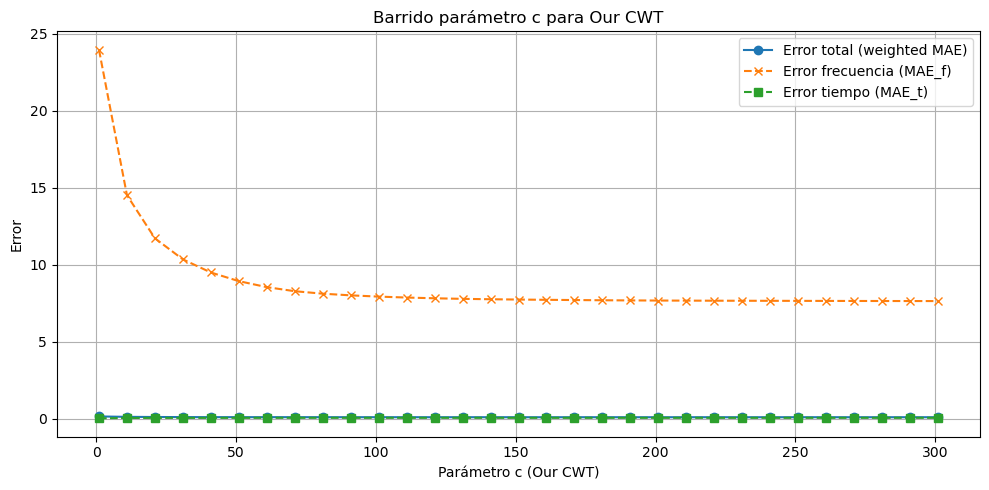


MÍNIMO 1D → parámetro c (Our CWT)
Mejor parámetro c = 221
Error mínimo total = 0.1016
Error mínimo frecuencia = 7.6677
Error mínimo tiempo = 0.0636


In [23]:
params_cwt = np.arange(1, 302, 10)

heatmap_f = np.zeros(len(params_cwt))
heatmap_t = np.zeros(len(params_cwt))
heatmap_total = np.zeros(len(params_cwt))

print("\n==========================================================")
print("        OUR CWT → Barrido 1D parámetro c")
print("==========================================================\n")

for i, c in enumerate(params_cwt):
    print(f"Checking parameter c = {c}")

    try:
        wavelet = f'cmor{c}-1.0'

        # Transformada CWT
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(test_signal, wavelet, freqs, fs)

        scalogram = np.array(jnp.abs(cwtmatr)**2)

        # --- Instant freq ---
        instant_freq = np.sum(scalogram * f[:, None], axis=0) / (np.sum(scalogram, axis=0) + 1e-12)
        instant_freq_burst = instant_freq[start_idx:end_idx]
        mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

        # --- Onset/offset ---
        t_on, t_off = get_onset_offset(
            scalogram,
            burst_start,
            burst_duration,
            t,
            fs,
            plot_data=False
        )
        mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

        # Métrica total ponderada
        total = w_f * mae_f + w_t * mae_t

    except Exception as e:
        print(f"ERROR parámetro c={c}: {e}")
        mae_f = mae_t = total = np.nan

    heatmap_f[i] = mae_f
    heatmap_t[i] = mae_t
    heatmap_total[i] = total

# -----------------------------------------------------------
# Graficar heatmap (en 1D solo curva)
plt.figure(figsize=(10, 5))
plt.plot(params_cwt, heatmap_total, marker='o', label='Error total (weighted MAE)')
plt.plot(params_cwt, heatmap_f, marker='x', linestyle='--', label='Error frecuencia (MAE_f)')
plt.plot(params_cwt, heatmap_t, marker='s', linestyle='--', label='Error tiempo (MAE_t)')

plt.xlabel('Parámetro c (Our CWT)')
plt.ylabel('Error')
plt.title('Barrido parámetro c para Our CWT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Localizar mínimo
idx_min = np.nanargmin(heatmap_total)
best_c = params_cwt[idx_min]

print("\n==========================================================")
print("MÍNIMO 1D → parámetro c (Our CWT)")
print("==========================================================")
print(f"Mejor parámetro c = {best_c}")
print(f"Error mínimo total = {heatmap_total[idx_min]:.4f}")
print(f"Error mínimo frecuencia = {heatmap_f[idx_min]:.4f}")
print(f"Error mínimo tiempo = {heatmap_t[idx_min]:.4f}")


# Superlet transform


             SUPERLET → Barrido COMPLETO 3D


===== baseCycle = 1 =====
Checking min order = 1
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302
Checking min order = 6
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302
Checking min order = 11
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302

===== baseCycle = 11 =====
Checking min order = 1
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 152
Checking max order = 202
Checking max order = 252
Checking max order = 302
Checking min order = 6
Checking max order = 2
Checking max order = 52
Checking max order = 102
Checking max order = 15

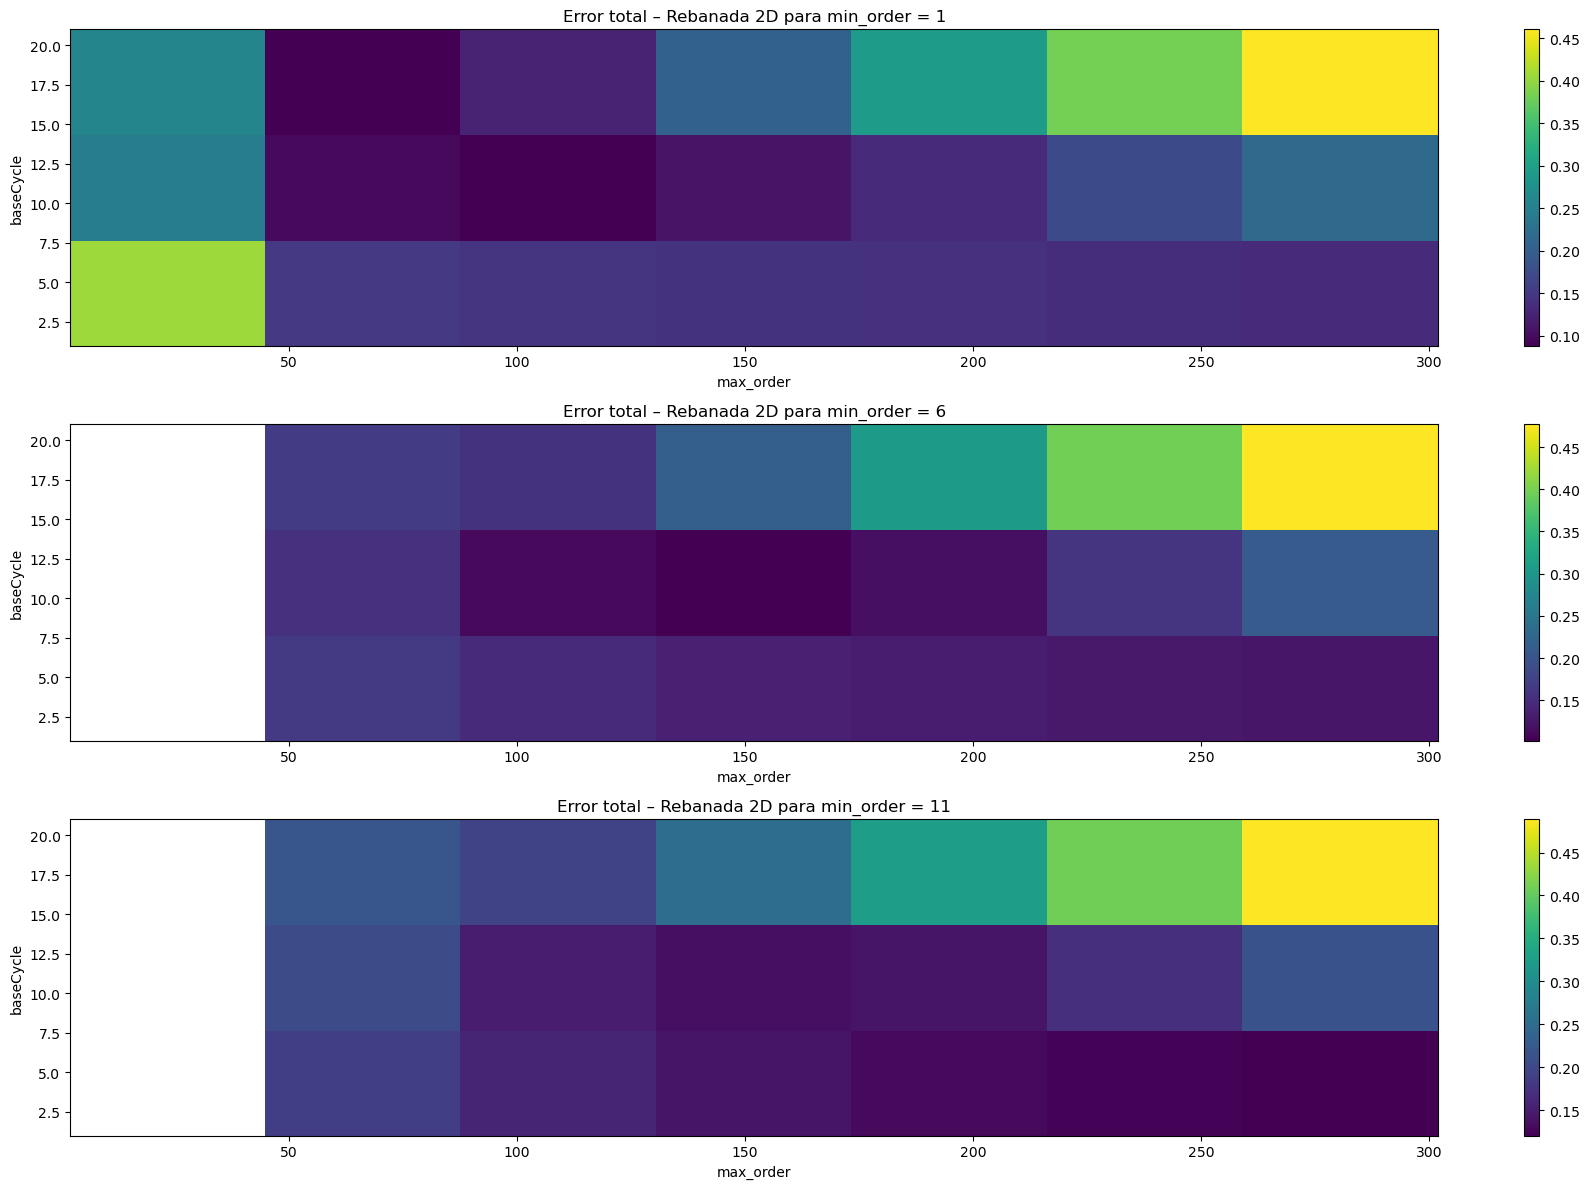

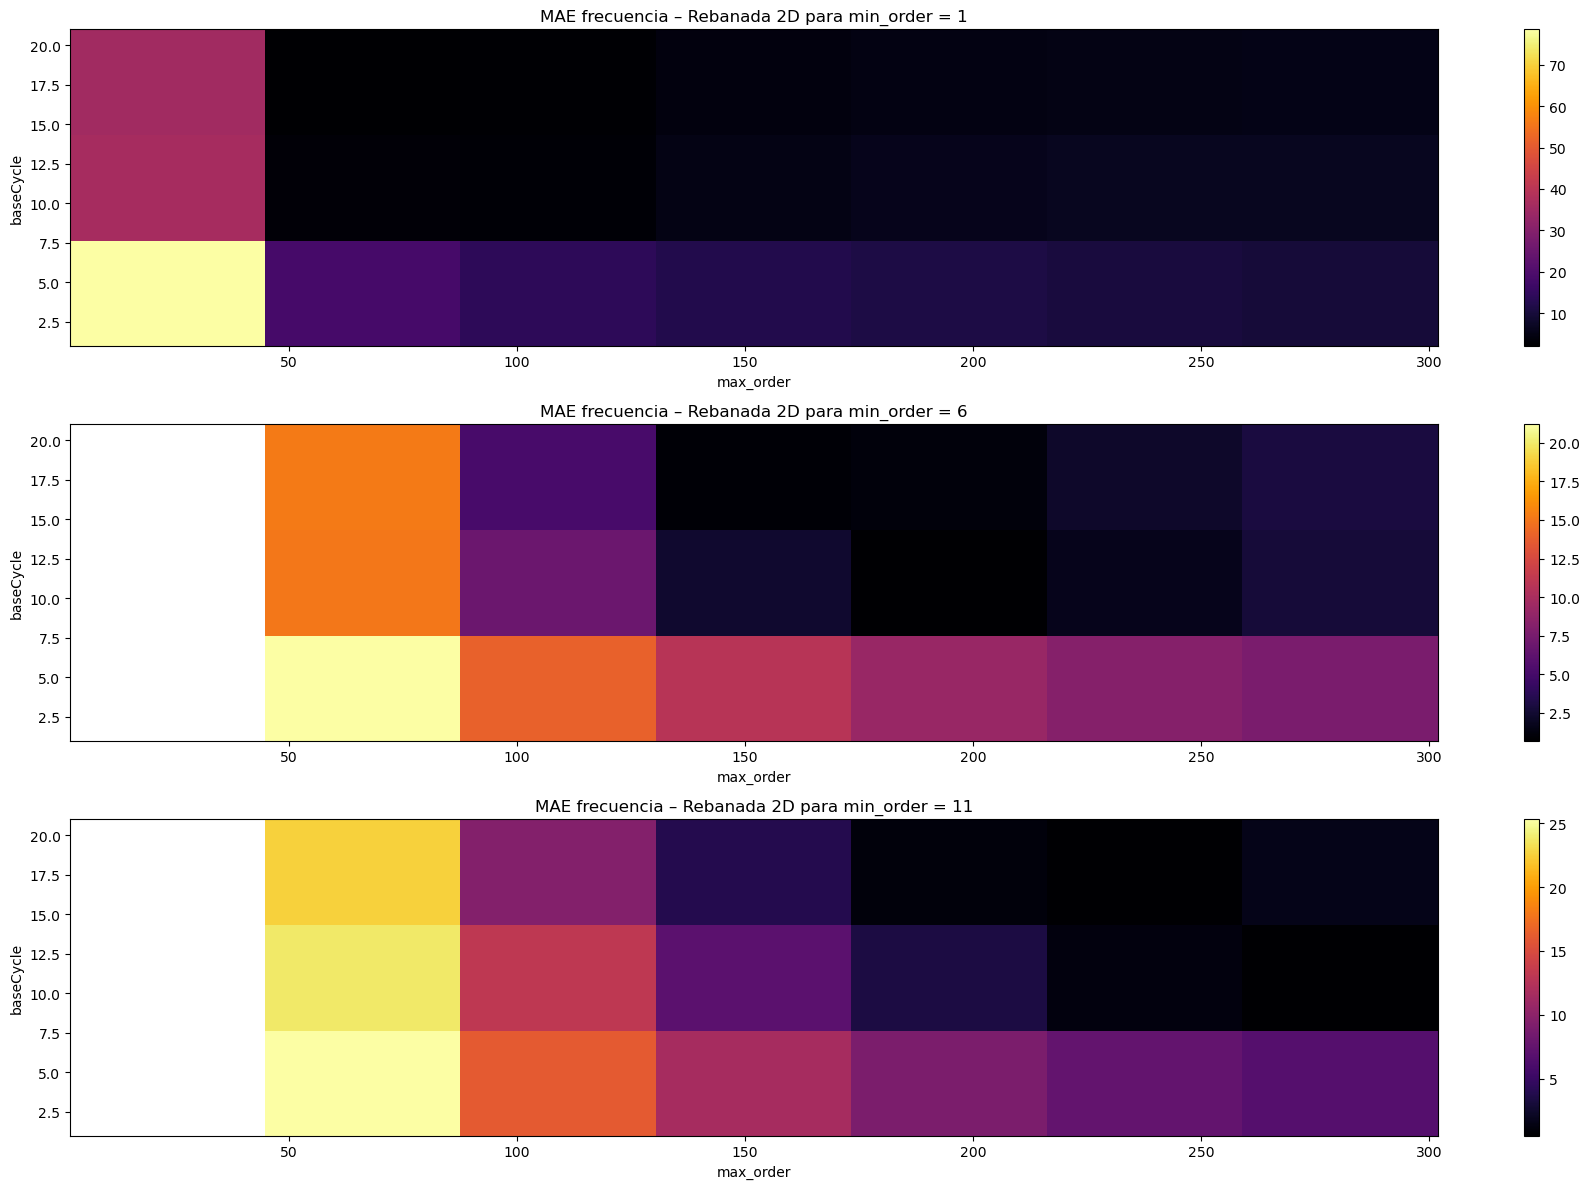

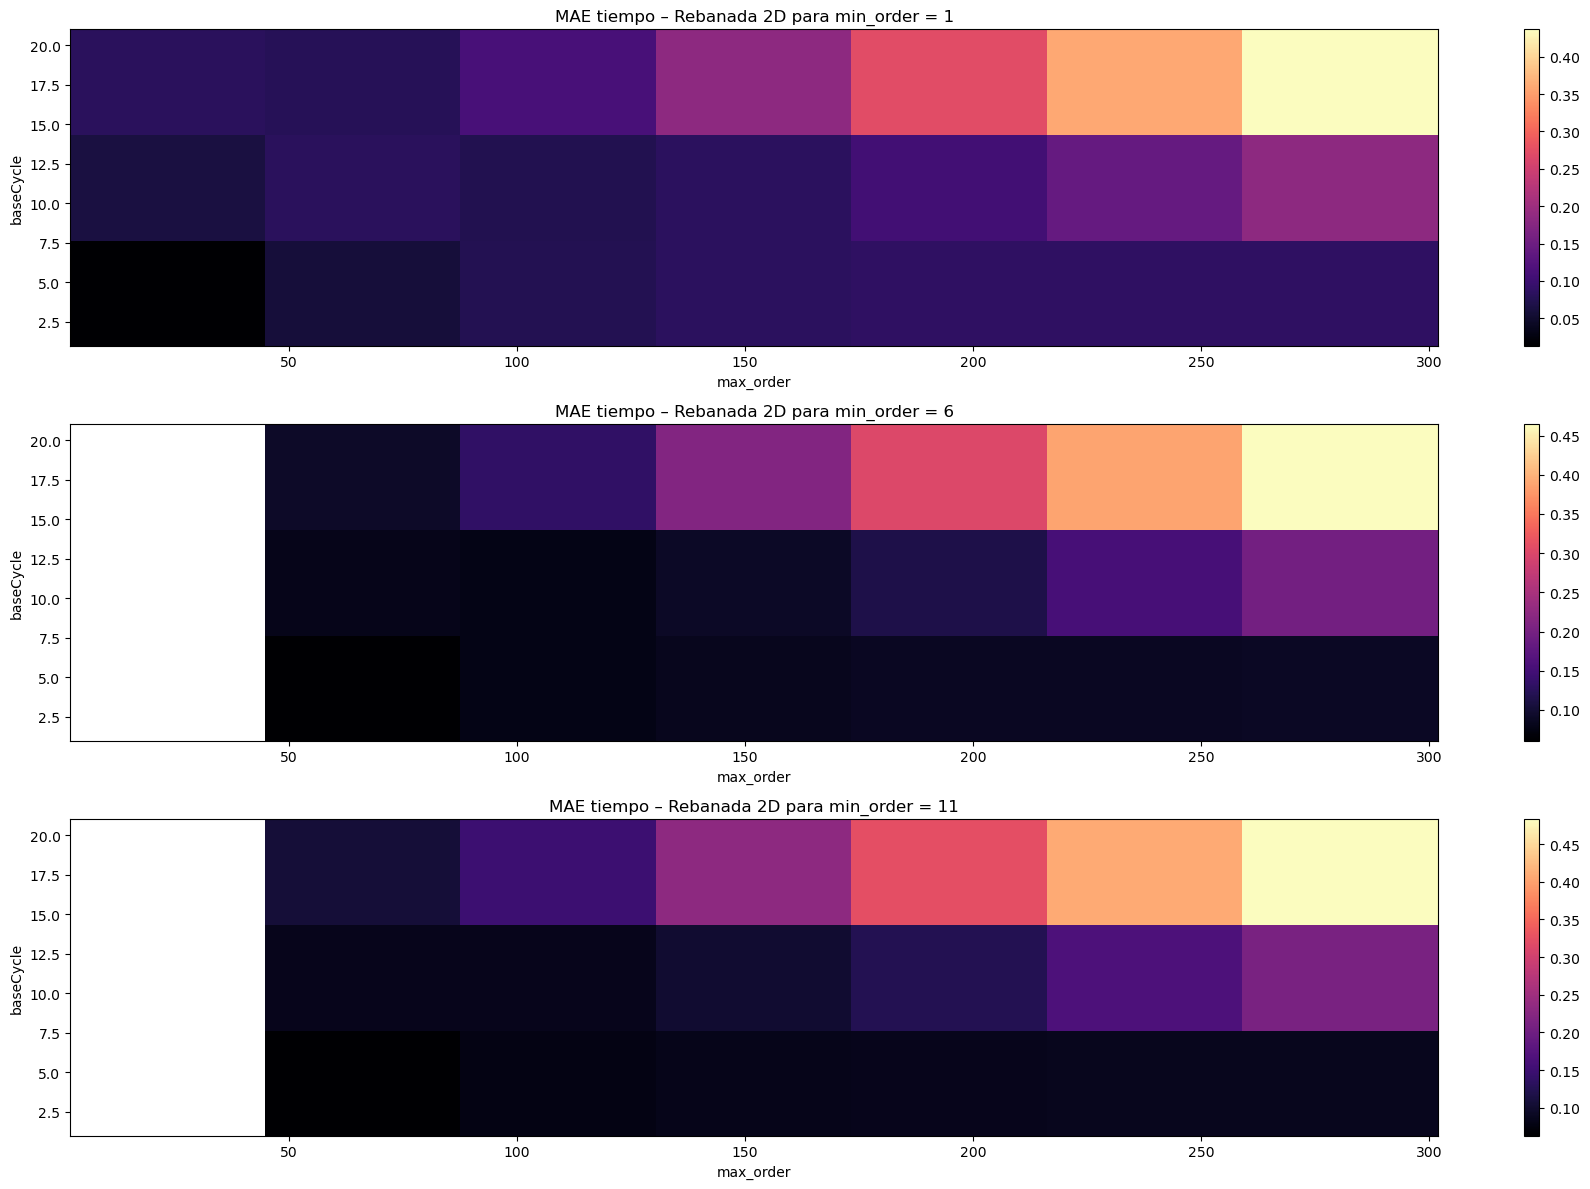

In [24]:
# ============================================================
#                 DEFINICIÓN DE PARRILLA 3D
# ============================================================

bases_3d = np.arange(1, 22, 10)          # eje baseCycle
min_orders_3d = np.arange(1, 12, 5)      # eje min_order
max_orders_3d = np.arange(2, 303, 50)    # eje max_order

heatmap_3d   = np.zeros((len(bases_3d), len(min_orders_3d), len(max_orders_3d)))
heatmap_f_3d = np.zeros((len(bases_3d), len(min_orders_3d), len(max_orders_3d)))
heatmap_t_3d = np.zeros((len(bases_3d), len(min_orders_3d), len(max_orders_3d)))

eps = 1e-12

print("\n==========================================================")
print("             SUPERLET → Barrido COMPLETO 3D")
print("==========================================================\n")

# ============================================================
# ================ BUCLE 3D PARA CALCULAR ERRORES =============
# ============================================================

for i, base in enumerate(bases_3d):
    print(f"\n===== baseCycle = {base} =====")

    for k, o_min in enumerate(min_orders_3d):
        print(f'Checking min order = {o_min}')

        for j, o_max in enumerate(max_orders_3d):
            print(f'Checking max order = {o_max}')

            # Evitar max_order < min_order
            if o_max <= o_min:
                heatmap_3d[i, k, j]   = np.nan
                heatmap_f_3d[i, k, j] = np.nan
                heatmap_t_3d[i, k, j] = np.nan
                continue

            try:
                # --------------------------------------------------
                #                   SUPERLET
                # --------------------------------------------------
                wv, sltRez = superlet.adaptive_superlet_transform(
                    test_signal,
                    freqs,
                    sampling_freq=fs,
                    base_cycle=base,
                    min_order=o_min,
                    max_order=o_max,
                    mode="mul"
                )

                sltRez_scalogram = np.array(jnp.abs(sltRez) ** 2)

                # ========== Instant freq ==========
                instant_freq = np.sum(
                    sltRez_scalogram * freqs[:, None], axis=0
                ) / (np.sum(sltRez_scalogram, axis=0) + eps)

                instant_freq_burst = instant_freq[start_idx:end_idx]
                mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

                # ========== Onset-offset ==========
                t_on, t_off = get_onset_offset(
                    sltRez_scalogram,
                    burst_start,
                    burst_duration,
                    t,
                    fs,
                    smooth_sigma,
                    plot=False
                )
                mae_t, _ = superlet.calculate_mae(
                    (t_on, t_off),
                    (real_t_onset, real_t_offset)
                )

                # ----------- Guardar errores separados -----------
                heatmap_f_3d[i, k, j] = mae_f
                heatmap_t_3d[i, k, j] = mae_t

                # ===== Métrica total =====
                total = w_f * mae_f + w_t * mae_t

            except Exception as e:
                print(f"ERROR base={base}, min={o_min}, max={o_max}: {e}")

                heatmap_3d[i, k, j]   = np.nan
                heatmap_f_3d[i, k, j] = np.nan
                heatmap_t_3d[i, k, j] = np.nan
                continue

            heatmap_3d[i, k, j] = total

# ============================================================
# ============== LOCALIZAR MÍNIMO GLOBAL 3D ==================
# ============================================================

idx = np.nanargmin(heatmap_3d)
best_i, best_k, best_j = np.unravel_index(idx, heatmap_3d.shape)

best_base = bases_3d[best_i]
best_min  = min_orders_3d[best_k]
best_max  = max_orders_3d[best_j]

print("\n==========================================================")
print("                 MÍNIMO GLOBAL 3D")
print("==========================================================")
print(f"Mejor baseCycle = {best_base}")
print(f"Mejor min_order = {best_min}")
print(f"Mejor max_order = {best_max}")
print(f"Error mínimo    = {heatmap_3d[best_i, best_k, best_j]:.4f}")

# ============================================================
# ===================== REBANADAS 2D =========================
# ============================================================

# ------------------------------------------------------------
# Rebanadas – Error TOTAL
# ------------------------------------------------------------
plt.figure(figsize=(18, 4 * len(min_orders_3d)))

for k, o_min in enumerate(min_orders_3d):

    slice_2d = heatmap_3d[:, k, :]   # baseCycle × max_order

    ax = plt.subplot(len(min_orders_3d), 1, k + 1)

    im = ax.imshow(
        slice_2d,
        origin="lower",
        cmap="viridis",
        aspect="auto",
        extent=[max_orders_3d[0], max_orders_3d[-1],
                bases_3d[0], bases_3d[-1]]
    )

    ax.set_title(f"Error total – Rebanada 2D para min_order = {o_min}")
    ax.set_xlabel("max_order")
    ax.set_ylabel("baseCycle")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Rebanadas – Error en FRECUENCIA
# ------------------------------------------------------------
plt.figure(figsize=(18, 4 * len(min_orders_3d)))

for k, o_min in enumerate(min_orders_3d):

    slice_f = heatmap_f_3d[:, k, :]

    ax = plt.subplot(len(min_orders_3d), 1, k + 1)

    im = ax.imshow(
        slice_f,
        origin="lower",
        cmap="inferno",
        aspect="auto",
        extent=[max_orders_3d[0], max_orders_3d[-1],
                bases_3d[0], bases_3d[-1]]
    )

    ax.set_title(f"MAE frecuencia – Rebanada 2D para min_order = {o_min}")
    ax.set_xlabel("max_order")
    ax.set_ylabel("baseCycle")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Rebanadas – Error en TIEMPO
# ------------------------------------------------------------
plt.figure(figsize=(18, 4 * len(min_orders_3d)))

for k, o_min in enumerate(min_orders_3d):

    slice_t = heatmap_t_3d[:, k, :]

    ax = plt.subplot(len(min_orders_3d), 1, k + 1)

    im = ax.imshow(
        slice_t,
        origin="lower",
        cmap="magma",
        aspect="auto",
        extent=[max_orders_3d[0], max_orders_3d[-1],
                bases_3d[0], bases_3d[-1]]
    )

    ax.set_title(f"MAE tiempo – Rebanada 2D para min_order = {o_min}")
    ax.set_xlabel("max_order")
    ax.set_ylabel("baseCycle")

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


# STFT


        STFT → Barrido 1D parámetro W

Checking parameter w = 2
Checking parameter w = 12
Checking parameter w = 22
Checking parameter w = 32
Checking parameter w = 42
Checking parameter w = 52
Checking parameter w = 62
Checking parameter w = 72
Checking parameter w = 82
Checking parameter w = 92
Checking parameter w = 102
Checking parameter w = 112
Checking parameter w = 122
Checking parameter w = 132
Checking parameter w = 142
Checking parameter w = 152
Checking parameter w = 162
Checking parameter w = 172
Checking parameter w = 182
Checking parameter w = 192
Checking parameter w = 202
Checking parameter w = 212
Checking parameter w = 222
Checking parameter w = 232
Checking parameter w = 242
Checking parameter w = 252
Checking parameter w = 262
Checking parameter w = 272
Checking parameter w = 282
Checking parameter w = 292


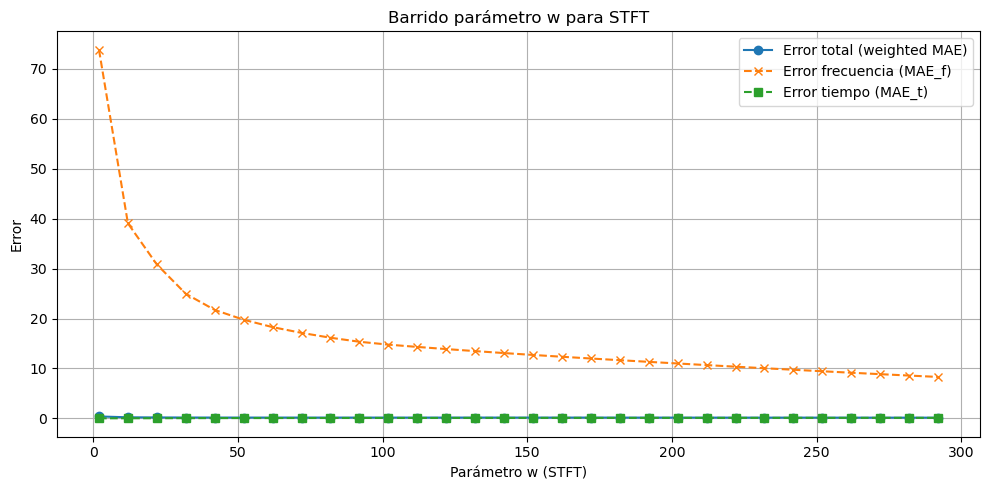


MÍNIMO 1D → parámetro w (STFT)
Mejor parámetro c = 292
Error mínimo total = 0.1359
Error mínimo frecuencia = 8.2954
Error mínimo tiempo = 0.0949


In [25]:
from scipy.signal import stft, windows

params_cwt = np.arange(2, 302, 10)

heatmap_f = np.zeros(len(params_cwt))
heatmap_t = np.zeros(len(params_cwt))
heatmap_total = np.zeros(len(params_cwt))

print("\n==========================================================")
print("        STFT → Barrido 1D parámetro W")
print("==========================================================\n")

for i, c in enumerate(params_cwt):
    print(f"Checking parameter w = {c}")

    try:
        window = windows.blackman(c)

        f, t_stft, Zxx = stft(
            test_signal, fs=fs, window=window, nperseg=c, noverlap=c-1, nfft=nfft,
            detrend=False, return_onesided=True, boundary='zeros', padded=True, axis=-1, scaling='spectrum'
        )

        Zxx_power = np.abs(Zxx) ** 2
        scalogram = Zxx_power
    

        # --- Instant freq ---
        instant_freq = np.sum(scalogram * f[:, None], axis=0) / (np.sum(scalogram, axis=0) + eps)
        instant_freq_burst = instant_freq[start_idx:end_idx]
        mae_f, _ = superlet.calculate_mae(instant_freq_burst, MNF_1[0])

        first_indices = []
        last_indices = []
        
        for row in scalogram:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t_stft, fs, smooth_sigma=smooth_sigma, plot=False, contamination=contamination)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t_stft[first_indices]
        t_offset = t_stft[last_indices]
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        # Métrica total ponderada
        total = w_f * mae_f + w_t * mae_t

    except Exception as e:
        print(f"ERROR parámetro c={c}: {e}")
        mae_f = mae_t = total = np.nan

    heatmap_f[i] = mae_f
    heatmap_t[i] = mae_t
    heatmap_total[i] = total

# -----------------------------------------------------------
# Graficar heatmap (en 1D solo curva)
plt.figure(figsize=(10, 5))
plt.plot(params_cwt, heatmap_total, marker='o', label='Error total (weighted MAE)')
plt.plot(params_cwt, heatmap_f, marker='x', linestyle='--', label='Error frecuencia (MAE_f)')
plt.plot(params_cwt, heatmap_t, marker='s', linestyle='--', label='Error tiempo (MAE_t)')

plt.xlabel('Parámetro w (STFT)')
plt.ylabel('Error')
plt.title('Barrido parámetro w para STFT')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Localizar mínimo
idx_min = np.nanargmin(heatmap_total)
best_c = params_cwt[idx_min]

print("\n==========================================================")
print("MÍNIMO 1D → parámetro w (STFT)")
print("==========================================================")
print(f"Mejor parámetro c = {best_c}")
print(f"Error mínimo total = {heatmap_total[idx_min]:.4f}")
print(f"Error mínimo frecuencia = {heatmap_f[idx_min]:.4f}")
print(f"Error mínimo tiempo = {heatmap_t[idx_min]:.4f}")


# BAYESIAN

# OPTIMIZE SUPERLET PARAMETERS

# CWT

In [26]:
import optuna

def objective_our_cwt(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    # Optimizar número de ciclos de la wavelet entre 1 y 100
    c = trial.suggest_int('num_cycles', 1, 300)
    wavelet = f'cmor{c}-1.0'

    try:
        # Transformada CWT
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(test_signal, wavelet, freqs, fs)

        # Escalograma al cuadrado
        scalogram_2 = np.array(jnp.abs(cwtmatr)**2)

        # Frecuencia instantánea promedio
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        
        # Energía total por tiempo
        t_on, t_off = get_onset_offset(
            scalogram_2,
            burst_start,
            burst_duration,
            t,
            fs,
            smooth_sigma,
            plot=False
        )

        # MAE tiempo
        mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

        # print(f"[Trial {trial.number}] c={c} → MAE_f: {mae_f:.4f}, MAE_t: {mae_t:.4f}")

        return mae_f, mae_t

    except Exception as e:
        print(f"[Trial {trial.number}] ERROR: {e}")
        return float('inf'), float('inf')


study_our_cwt = optuna.create_study(directions=["minimize", "minimize"])
study_our_cwt.optimize(objective_our_cwt, n_trials=200)

[I 2025-12-02 09:14:23,994] A new study created in memory with name: no-name-b7ed1826-356c-4e7f-90c2-183c481c0c10
[I 2025-12-02 09:14:24,270] Trial 0 finished with values: [7.720721455672502, 0.0635188558287203] and parameters: {'num_cycles': 164}.
[I 2025-12-02 09:14:24,513] Trial 1 finished with values: [7.8673279898634485, 0.06407343902637577] and parameters: {'num_cycles': 112}.
[I 2025-12-02 09:14:24,755] Trial 2 finished with values: [7.8889177416017855, 0.06407820895066754] and parameters: {'num_cycles': 108}.
[I 2025-12-02 09:14:25,000] Trial 3 finished with values: [7.972946260896961, 0.06393924515630087] and parameters: {'num_cycles': 96}.
[I 2025-12-02 09:14:25,243] Trial 4 finished with values: [7.7131634939218845, 0.06340278767095409] and parameters: {'num_cycles': 169}.
[I 2025-12-02 09:14:25,491] Trial 5 finished with values: [7.663359258058631, 0.06367212939596223] and parameters: {'num_cycles': 233}.
[I 2025-12-02 09:14:25,739] Trial 6 finished with values: [7.79789365

In [27]:
seen = set()
unique_best = []

for trial in sorted(study_our_cwt.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    print(f"{i}. {params} → MAE_f = {trial.values[0]:.4f}, MAE_t = {trial.values[1]:.4f}")

best_weighted = min(study_our_cwt.trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):")
print(f"{best_weighted.params} → "
      f"MAE_f = {best_weighted.values[0]:.4f}, MAE_t = {best_weighted.values[1]:.4f}, "
      f"Score = {w_f * best_weighted.values[0] + w_t * best_weighted.values[1]:.4f}")

best_f = min(study_our_cwt.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"{best_f.params} → MAE_f = {best_f.values[0]:.4f}, MAE_t = {best_f.values[1]:.4f}")

best_t = min(study_our_cwt.trials, key=lambda x: x.values[1])
print("\n⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"{best_t.params} → MAE_f = {best_t.values[0]:.4f}, MAE_t = {best_t.values[1]:.4f}")


# --- Visualización del frente de Pareto ---
mae_f_vals_our_wavelet = [b.values[0] for b in study_our_cwt.trials]
mae_t_vals_our_wavelet = [b.values[1] for b in study_our_cwt.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. {'num_cycles': 227} → MAE_f = 7.6655, MAE_t = 0.0635
2. {'num_cycles': 256} → MAE_f = 7.6555, MAE_t = 0.0636
3. {'num_cycles': 295} → MAE_f = 7.6449, MAE_t = 0.0637

🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):
{'num_cycles': 227} → MAE_f = 7.6655, MAE_t = 0.0635, Score = 0.1015

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
{'num_cycles': 295} → MAE_f = 7.6449, MAE_t = 0.0637

⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):
{'num_cycles': 3} → MAE_f = 19.5885, MAE_t = 0.0378


# Superlet

In [28]:
import optuna

def objective_superlet(trial):
    seed = trial.number  # Semilla única por prueba
    np.random.seed(seed)
    
    base = trial.suggest_int('base_cycle', 1, 20)
    min_o = trial.suggest_int('min_order', 1, 10)
    max_o = trial.suggest_int('max_order', 50, 300)

    if min_o > max_o:
        return float('inf'), float('inf')

    try:
        _, scalogram = superlet.adaptive_superlet_transform(
            test_signal, freqs, sampling_freq=fs,
            base_cycle=base, min_order=min_o,
            max_order=max_o, mode="mul"
        )

        scalogram_2 = np.abs(scalogram)**2
        instant_freq = np.sum(scalogram_2 * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        
        # ========== Onset-offset ==========
        t_on, t_off = get_onset_offset(
            scalogram_2,
            burst_start,
            burst_duration,
            t,
            fs,
            smooth_sigma,
            plot=False
        )
        
        mae_t, _ = superlet.calculate_mae((t_on, t_off), (real_t_onset, real_t_offset))

        return mae_f, mae_t

    except Exception as e:
        return float('inf'), float('inf')

study_superlet = optuna.create_study(directions=["minimize", "minimize"])
study_superlet.optimize(objective_superlet, n_trials=200)

[I 2025-12-02 09:15:34,212] A new study created in memory with name: no-name-069b90dd-d22e-4186-95e9-0c184c340c74
[I 2025-12-02 09:15:44,360] Trial 0 finished with values: [2.9247955987646677, 0.12059990383832628] and parameters: {'base_cycle': 16, 'min_order': 6, 'max_order': 133}.
[I 2025-12-02 09:15:49,557] Trial 1 finished with values: [7.583532552206712, 0.07714462156056659] and parameters: {'base_cycle': 8, 'min_order': 5, 'max_order': 81}.
[I 2025-12-02 09:16:14,379] Trial 2 finished with values: [1.174341690914983, 0.08913144130576359] and parameters: {'base_cycle': 7, 'min_order': 7, 'max_order': 256}.
[I 2025-12-02 09:16:24,173] Trial 3 finished with values: [4.6481624608609335, 0.10407656809671116] and parameters: {'base_cycle': 14, 'min_order': 1, 'max_order': 152}.
[I 2025-12-02 09:16:44,461] Trial 4 finished with values: [3.3234339025862285, 0.242756074975578] and parameters: {'base_cycle': 15, 'min_order': 4, 'max_order': 257}.
[I 2025-12-02 09:17:06,440] Trial 5 finishe

In [29]:
# Obtener los trials únicos de la frontera de Pareto, según combinación de parámetros
seen = set()
unique_best = []

for trial in sorted(study_superlet.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

# Imprimir configuraciones únicas del Pareto front
print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    mae_f, mae_t = trial.values
    print(f"{i}. base_cycle={params['base_cycle']}, min_order={params['min_order']}, max_order={params['max_order']} → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

# Obtener el mejor resultado único (mínima suma de errores)
# best = min(unique_best, key=lambda x: sum(x.values))
best = min(unique_best, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación única (f + t mínimas):")
print(f"base_cycle={best.params['base_cycle']}, min_order={best.params['min_order']}, max_order={best.params['max_order']}")
print(f"MAE_f={best.values[0]:.4f}, MAE_t={best.values[1]:.4f}")

# Obtener el trial con menor error solo en frecuencia (MAE_f)
best_f = min(study_superlet.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"base_cycle={best_f.params['base_cycle']}, min_order={best_f.params['min_order']}, max_order={best_f.params['max_order']}")
print(f"MAE_f={best_f.values[0]:.4f}, MAE_t={best_f.values[1]:.4f}")

# Obtener el trial con menor error solo en tiempo (MAE_t)
best_t = min(study_superlet.trials, key=lambda x: x.values[1])
print("\n⚡ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"base_cycle={best_t.params['base_cycle']}, min_order={best_t.params['min_order']}, max_order={best_t.params['max_order']}")
print(f"MAE_f={best_t.values[0]:.4f}, MAE_t={best_t.values[1]:.4f}")


# Visualización rápida del pareto front
mae_f_vals_superlet = [b.values[0] for b in study_superlet.trials]
mae_t_vals_superlet = [b.values[1] for b in study_superlet.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. base_cycle=6, min_order=7, max_order=201 → MAE_f=1.8240, MAE_t=0.0725
2. base_cycle=6, min_order=6, max_order=231 → MAE_f=1.4994, MAE_t=0.0748
3. base_cycle=11, min_order=2, max_order=102 → MAE_f=1.6283, MAE_t=0.0741

🎯 Mejor combinación única (f + t mínimas):
base_cycle=6, min_order=7, max_order=201
MAE_f=1.8240, MAE_t=0.0725

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
base_cycle=18, min_order=7, max_order=201
MAE_f=0.3964, MAE_t=0.2421

⚡ Mejor combinación solo en tiempo (mínimo MAE_t):
base_cycle=1, min_order=4, max_order=54
MAE_f=19.2341, MAE_t=0.0606


# STFT

In [30]:
def objective_stft(trial):
    seed = trial.number
    np.random.seed(seed)
    
    num_cycles = trial.suggest_int('num_cycles', 2, 300)
    w = int(num_cycles * ms_per_cycle)

    # Evitar casos inválidos donde la ventana sea mayor que nfft fijo
    if w > nfft:
        return float('inf'), float('inf')

    try:
        window = windows.blackman(w)
        
        f, t_stft, Zxx = stft(
            test_signal, fs=fs, window=window,
            nperseg=w, noverlap=w-1,
            nfft=nfft,
            detrend=False, return_onesided=True,
            boundary='zeros', padded=True,
            axis=-1, scaling='spectrum'
        )
        
        Zxx_power = np.abs(Zxx) ** 2
        scalogram_2 = Zxx_power

        denominador = np.sum(scalogram_2, axis=0)
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.where(denominador == 0, eps, denominador)

        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(
                row, burst_start, burst_duration, t_stft, fs,
                smooth_sigma=smooth_sigma, plot=False, contamination=contamination
            )
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t_stft[first_indices]
        t_offset = t_stft[last_indices]

        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        return mae_f, mae_t

    except Exception as e:
        print(f"[Trial {trial.number}] ERROR: {e}")
        return float('inf'), float('inf')

study_stft = optuna.create_study(directions=["minimize", "minimize"])
study_stft.optimize(objective_stft, n_trials=200)

[I 2025-12-02 09:57:24,075] A new study created in memory with name: no-name-adab4f73-64fc-4287-9a5d-126220876824
[I 2025-12-02 09:57:24,079] Trial 0 finished with values: [inf, inf] and parameters: {'num_cycles': 152}.
[I 2025-12-02 09:57:24,080] Trial 1 finished with values: [inf, inf] and parameters: {'num_cycles': 237}.
[I 2025-12-02 09:57:24,081] Trial 2 finished with values: [inf, inf] and parameters: {'num_cycles': 213}.
[I 2025-12-02 09:57:24,082] Trial 3 finished with values: [inf, inf] and parameters: {'num_cycles': 176}.
[I 2025-12-02 09:57:24,083] Trial 4 finished with values: [inf, inf] and parameters: {'num_cycles': 134}.
[I 2025-12-02 09:57:24,216] Trial 5 finished with values: [16.717036528298266, 0.06890286153752437] and parameters: {'num_cycles': 6}.
[I 2025-12-02 09:57:24,337] Trial 6 finished with values: [5.736841772724974, 0.09516439753898635] and parameters: {'num_cycles': 32}.
[I 2025-12-02 09:57:24,338] Trial 7 finished with values: [inf, inf] and parameters: {

In [31]:
seen = set()
unique_best = []

for trial in sorted(study_stft.best_trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1]):
    params_tuple = tuple(sorted(trial.params.items()))
    if params_tuple not in seen:
        seen.add(params_tuple)
        unique_best.append(trial)
    if len(unique_best) == 3:
        break

print("\n🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):")
for i, trial in enumerate(unique_best, 1):
    params = trial.params
    print(f"{i}. {params} → MAE_f = {trial.values[0]:.4f}, MAE_t = {trial.values[1]:.4f}")

best_weighted = min(study_stft.trials, key=lambda x: w_f * x.values[0] + w_t * x.values[1])
print("\n🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):")
print(f"{best_weighted.params} → "
      f"MAE_f = {best_weighted.values[0]:.4f}, MAE_t = {best_weighted.values[1]:.4f}, "
      f"Score = {w_f * best_weighted.values[0] + w_t * best_weighted.values[1]:.4f}")

best_f = min(study_stft.trials, key=lambda x: x.values[0])
print("\n⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):")
print(f"{best_f.params} → MAE_f = {best_f.values[0]:.4f}, MAE_t = {best_f.values[1]:.4f}")

best_t = min(study_stft.trials, key=lambda x: x.values[1])
print("\n⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):")
print(f"{best_t.params} → MAE_f = {best_t.values[0]:.4f}, MAE_t = {best_t.values[1]:.4f}")


# --- Visualización del frente de Pareto ---
mae_f_vals_stft = [b.values[0] for b in study_stft.trials]
mae_t_vals_stft = [b.values[1] for b in study_stft.trials]


🔥 Top 3 mejores combinaciones únicas (menor mae_f + mae_t):
1. {'num_cycles': 51} → MAE_f = 3.8722, MAE_t = 0.0958
2. {'num_cycles': 56} → MAE_f = 3.7790, MAE_t = 0.0965
3. {'num_cycles': 44} → MAE_f = 4.2397, MAE_t = 0.0944

🎯 Mejor combinación total ponderada (w_f * MAE_f + w_t * MAE_t):
{'num_cycles': 51} → MAE_f = 3.8722, MAE_t = 0.0958, Score = 0.1147

⚡ Mejor combinación solo en frecuencia (mínimo MAE_f):
{'num_cycles': 56} → MAE_f = 3.7790, MAE_t = 0.0965

⏱️ Mejor combinación solo en tiempo (mínimo MAE_t):
{'num_cycles': 2} → MAE_f = 28.8710, MAE_t = 0.0299


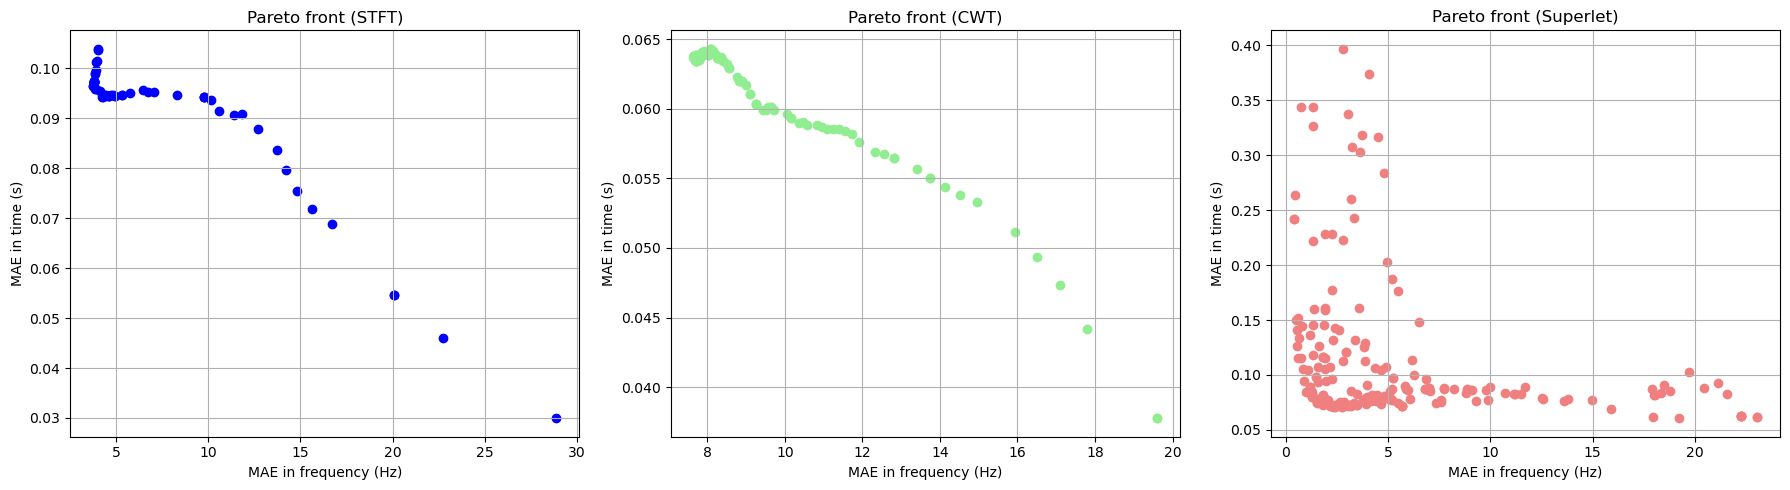

In [32]:
import matplotlib.pyplot as plt

# Calcula los límites a partir de los datos de Superlet
# x_min = min(mae_f_vals_superlet)
# x_max = max(mae_f_vals_superlet)
# y_min = min(mae_t_vals_superlet)
# y_max = max(mae_t_vals_superlet)
# 
# # Agrega márgenes
# x_margin = (x_max - x_min) * 0.05
# y_margin = (y_max - y_min) * 0.05
# xlim = (x_min - x_margin, x_max + x_margin)
# ylim = (y_min - y_margin, y_max + y_margin)

# Crear figura con 3 subplots en una fila
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Superlet
axs[0].scatter(mae_f_vals_stft, mae_t_vals_stft, c='blue')
axs[0].set_title("Pareto front (STFT)")
axs[0].set_xlabel("MAE in frequency (Hz)")
axs[0].set_ylabel("MAE in time (s)")
# axs[0].set_xlim(xlim)
# axs[0].set_ylim(ylim)
# axs[0].set_xlim(0,30)
# axs[0].set_ylim(0,0.16)
axs[0].grid(True)

# Wavelet
axs[1].scatter(mae_f_vals_our_wavelet, mae_t_vals_our_wavelet, c='lightgreen')
axs[1].set_title("Pareto front (CWT)")
axs[1].set_xlabel("MAE in frequency (Hz)")
axs[1].set_ylabel("MAE in time (s)")
# axs[1].set_xlim(0,30)
# axs[1].set_ylim(0,0.16)
axs[1].grid(True)

# STFT
axs[2].scatter(mae_f_vals_superlet, mae_t_vals_superlet, c='lightcoral')
axs[2].set_title("Pareto front (Superlet)")
axs[2].set_xlabel("MAE in frequency (Hz)")
axs[2].set_ylabel("MAE in time (s)")
# axs[2].set_xlim(0,30)
# axs[2].set_ylim(0,0.16)
# axs[2].set_ylim(ylim)
axs[2].grid(True)

# Ajustar espacio
plt.tight_layout()
plt.show()


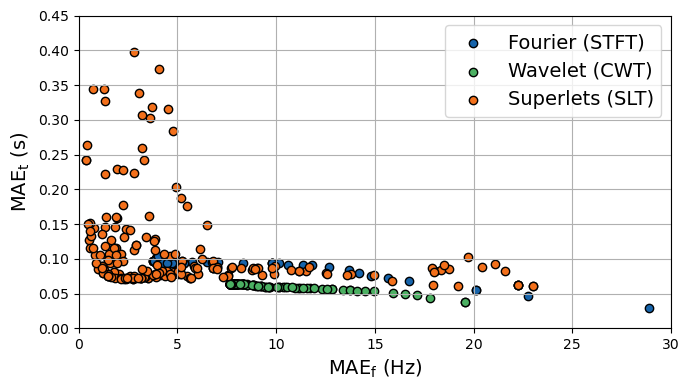

In [48]:
# Asumiendo que ya tienes los resultados de cada uno:
# listas de tuplas/lists: (mae_f, mae_t) para cada trial exitoso

colores_base = {                                 
    "STFT": plt.colormaps["Blues"],              
    "Wavelet": plt.colormaps["Greens"],          
    "Superlet": plt.colormaps["Oranges"],        
}        

wavelet_vals = [
    (trial.values[0], trial.values[1]) 
    for trial in study_our_cwt.trials 
    if trial.values is not None
]
stft_vals = [
    (trial.values[0], trial.values[1]) 
    for trial in study_stft.trials 
    if trial.values is not None
]

superlet_vals = [
    (trial.values[0], trial.values[1]) 
    for trial in study_superlet.trials 
    if trial.values is not None
]

# Separar coordenadas
stft_f, stft_t = zip(*stft_vals)
wavelet_f, wavelet_t = zip(*wavelet_vals)
superlet_f, superlet_t = zip(*superlet_vals)

# Plot
plt.figure(figsize=(7, 4))
plt.scatter(stft_f, stft_t, color=colores_base["STFT"](0.8), label='Fourier (STFT)', edgecolor='black')
plt.scatter(wavelet_f, wavelet_t, color=colores_base["Wavelet"](0.6), label='Wavelet (CWT)', edgecolor='black')
plt.scatter(superlet_f, superlet_t, color=colores_base["Superlet"](0.6), label='Superlets (SLT)', edgecolor='black')

plt.xticks(np.arange(0, 31, 5))

plt.ylim(0,0.45)
plt.xlim(0,30)

plt.xlabel("$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylabel("$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)
# plt.title("Pareto front (all values)", fontsize=fontsize_title)
plt.grid(True)
plt.legend(fontsize=fontsize_legend)
plt.tight_layout()
plt.show()


# RANDOM SEARCH

# CWT

In [34]:
import random
import numpy as np

random_trials_our_cwt = []
total_trials = 200
successful_trials = 0

print(f"🔍 Iniciando Random Search para nuestra CWT con {total_trials} combinaciones aleatorias...\n")

for i in range(total_trials):
    c = random.randint(1, 150)
    wavelet = f'cmor{c}-1.0'

    print(f"🎲 Trial {i+1}/{total_trials}: wavelet={wavelet}...", end=" ")

    try:
        cwtmatr, f, physical_freqs = morlet.wavelet_transform_2(test_signal, wavelet, freqs, fs)
    
        scalogram_2 = np.array(jnp.abs(cwtmatr)**2)
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
    
        t_onset = t[first_indices]
        t_offset = t[last_indices]
    
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))
    
        random_trials_our_cwt.append({
            'params': {'num_cycles': c},
            'mae_f': mae_f,
            'mae_t': mae_t
        })
    
        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finalizado. Se completaron {successful_trials}/{total_trials} pruebas exitosamente.")

🔍 Iniciando Random Search para nuestra CWT con 200 combinaciones aleatorias...

🎲 Trial 1/200: wavelet=cmor115-1.0... ✅ OK → MAE_f=7.8518, MAE_t=0.0639
🎲 Trial 2/200: wavelet=cmor122-1.0... ✅ OK → MAE_f=7.8209, MAE_t=0.0639
🎲 Trial 3/200: wavelet=cmor149-1.0... ✅ OK → MAE_f=7.7460, MAE_t=0.0637
🎲 Trial 4/200: wavelet=cmor22-1.0... ✅ OK → MAE_f=11.5472, MAE_t=0.0584
🎲 Trial 5/200: wavelet=cmor117-1.0... ✅ OK → MAE_f=7.8425, MAE_t=0.0640
🎲 Trial 6/200: wavelet=cmor105-1.0... ✅ OK → MAE_f=7.9065, MAE_t=0.0641
🎲 Trial 7/200: wavelet=cmor37-1.0... ✅ OK → MAE_f=9.7913, MAE_t=0.0598
🎲 Trial 8/200: wavelet=cmor82-1.0... ✅ OK → MAE_f=8.1111, MAE_t=0.0642
🎲 Trial 9/200: wavelet=cmor48-1.0... ✅ OK → MAE_f=9.0871, MAE_t=0.0611
🎲 Trial 10/200: wavelet=cmor118-1.0... ✅ OK → MAE_f=7.8381, MAE_t=0.0640
🎲 Trial 11/200: wavelet=cmor31-1.0... ✅ OK → MAE_f=10.3516, MAE_t=0.0590
🎲 Trial 12/200: wavelet=cmor15-1.0... ✅ OK → MAE_f=13.0977, MAE_t=0.0561
🎲 Trial 13/200: wavelet=cmor72-1.0... ✅ OK → MAE_f=8.265

In [35]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials_our_cwt, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. cycles={p['num_cycles']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials_our_cwt, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"cycles={p['num_cycles']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. cycles=138 → MAE_f=7.7694, MAE_t=0.0635
2. cycles=138 → MAE_f=7.7694, MAE_t=0.0635
3. cycles=138 → MAE_f=7.7694, MAE_t=0.0635

🎯 Mejor combinación única (random):
cycles=138
MAE_f=7.7694, MAE_t=0.0635


# Superlet

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import random

random_trials = []
total_trials = 200
successful_trials = 0

print(f"🔍 Iniciando Random Search con {total_trials} combinaciones aleatorias...\n")

for i in range(total_trials):
    base = random.randint(1, 20)
    min_o = random.randint(1, 10)
    max_o = random.randint(50, 300)

    print(f"🎲 Trial {i+1}/{total_trials}: base_cycle={base}, min_order={min_o}, max_order={max_o}...", end=" ")

    if min_o > max_o:
        print("❌ Saltado (min_order > max_order)")
        continue

    try:
        _, scalogram = superlet.adaptive_superlet_transform(
            test_signal, freqs, sampling_freq=fs,
            base_cycle=base, min_order=min_o,
            max_order=max_o, mode="mul"
        )

        scalogram_2 = np.abs(scalogram)**2
        instant_freq = np.sum(scalogram_2 * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_2, axis=0)
        energia_temporal = scalogram_2

        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(row, burst_start, burst_duration, t, fs, smooth_sigma=smooth_sigma, plot=False, contamination=False)
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t[first_indices]
        t_offset = t[last_indices]
        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        random_trials.append({
            'params': {'base_cycle': base, 'min_order': min_o, 'max_order': max_o},
            'mae_f': mae_f,
            'mae_t': mae_t
        })

        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finalizado. Se completaron {successful_trials}/{total_trials} pruebas exitosamente.")

🔍 Iniciando Random Search con 200 combinaciones aleatorias...

🎲 Trial 1/200: base_cycle=16, min_order=2, max_order=275... ✅ OK → MAE_f=4.7955, MAE_t=0.2841
🎲 Trial 2/200: base_cycle=19, min_order=5, max_order=147... ✅ OK → MAE_f=0.6773, MAE_t=0.1688
🎲 Trial 3/200: base_cycle=17, min_order=7, max_order=62... ✅ OK → MAE_f=14.7432, MAE_t=0.0869
🎲 Trial 4/200: base_cycle=6, min_order=2, max_order=96... ✅ OK → MAE_f=3.6830, MAE_t=0.0809
🎲 Trial 5/200: base_cycle=12, min_order=2, max_order=243... ✅ OK → MAE_f=4.9338, MAE_t=0.1556
🎲 Trial 6/200: base_cycle=7, min_order=10, max_order=66... ✅ OK → MAE_f=17.9229, MAE_t=0.0804
🎲 Trial 7/200: base_cycle=18, min_order=5, max_order=90... ✅ OK → MAE_f=5.8330, MAE_t=0.0991
🎲 Trial 8/200: base_cycle=14, min_order=5, max_order=56... ✅ OK → MAE_f=12.4840, MAE_t=0.0801
🎲 Trial 9/200: base_cycle=19, min_order=10, max_order=293... ✅ OK → MAE_f=1.5954, MAE_t=0.4171
🎲 Trial 10/200: base_cycle=14, min_order=7, max_order=90... ✅ OK → MAE_f=9.5812, MAE_t=0.0856

In [37]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials, key=lambda x: x['mae_f'] + x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. base_cycle={p['base_cycle']}, min_order={p['min_order']}, max_order={p['max_order']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials, key=lambda x: x['mae_f'] + x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"base_cycle={p['base_cycle']}, min_order={p['min_order']}, max_order={p['max_order']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. base_cycle=17, min_order=6, max_order=179 → MAE_f=0.3916, MAE_t=0.1879
2. base_cycle=17, min_order=8, max_order=212 → MAE_f=0.3383, MAE_t=0.2421
3. base_cycle=18, min_order=9, max_order=225 → MAE_f=0.3168, MAE_t=0.2879

🎯 Mejor combinación única (random):
base_cycle=17, min_order=6, max_order=179
MAE_f=0.3916, MAE_t=0.1879


# STFT

In [38]:
random_trials_stft = []
total_trials = 200
successful_trials = 0

print(f"🔍 Starting Random Search for STFT with {total_trials} random configurations...\n")

for i in range(total_trials):
    num_cycles = random.randint(2, 300)
    w = int(num_cycles * ms_per_cycle)
    
    print(f"🎲 Trial {i+1}/{total_trials}: num_cycles={num_cycles}, window size={w}...", end=" ")

    # Evitar que la ventana sea mayor que nfft fijo
    if w > nfft:
        print("⚠️ Skipped: window size > nfft")
        continue

    try:
        window = windows.blackman(w)
        
        f, t_stft, Zxx = stft(
            test_signal, fs=fs, window=window,
            nperseg=w, noverlap=w-1,
            nfft=nfft,
            detrend=False, return_onesided=True,
            boundary='zeros', padded=True,
            axis=-1, scaling='spectrum'
        )
        
        Zxx_power = np.abs(Zxx) ** 2
        scalogram_2 = Zxx_power

        denominador = np.sum(scalogram_2, axis=0)
        instant_freq = np.sum(scalogram_2 * f[:, np.newaxis], axis=0) / np.where(denominador == 0, eps, denominador)

        energia_temporal = scalogram_2
    
        first_indices = []
        last_indices = []
        
        for row in energia_temporal:
            first_index, last_index = superlet.find_plateau_region(
                row, burst_start, burst_duration, t_stft, fs,
                smooth_sigma=smooth_sigma, plot=False, contamination=contamination
            )
            first_indices.append(first_index)
            last_indices.append(last_index)
        
        t_onset = t_stft[first_indices]
        t_offset = t_stft[last_indices]

        instant_mean_freq_burst = instant_freq[start_idx:end_idx]

        mae_f, _ = superlet.calculate_mae(instant_mean_freq_burst, MNF_1)
        mae_t, _ = superlet.calculate_mae((t_onset, t_offset), (real_t_onset, real_t_offset))

        random_trials_stft.append({
            'params': {'num_cycles': num_cycles},
            'mae_f': mae_f,
            'mae_t': mae_t
        })

        successful_trials += 1
        print(f"✅ OK → MAE_f={mae_f:.4f}, MAE_t={mae_t:.4f}")

    except Exception as e:
        print(f"⚠️ Error: {str(e)}")

print(f"\n✅ Finished. Completed {successful_trials}/{total_trials} successful trials.")

🔍 Starting Random Search for STFT with 200 random configurations...

🎲 Trial 1/200: num_cycles=122, window size=1545... ⚠️ Skipped: window size > nfft
🎲 Trial 2/200: num_cycles=193, window size=2445... ⚠️ Skipped: window size > nfft
🎲 Trial 3/200: num_cycles=236, window size=2990... ⚠️ Skipped: window size > nfft
🎲 Trial 4/200: num_cycles=143, window size=1811... ⚠️ Skipped: window size > nfft
🎲 Trial 5/200: num_cycles=228, window size=2888... ⚠️ Skipped: window size > nfft
🎲 Trial 6/200: num_cycles=139, window size=1761... ⚠️ Skipped: window size > nfft
🎲 Trial 7/200: num_cycles=84, window size=1064... ⚠️ Skipped: window size > nfft
🎲 Trial 8/200: num_cycles=56, window size=709... ✅ OK → MAE_f=3.7790, MAE_t=0.0965
🎲 Trial 9/200: num_cycles=280, window size=3547... ⚠️ Skipped: window size > nfft
🎲 Trial 10/200: num_cycles=116, window size=1469... ⚠️ Skipped: window size > nfft
🎲 Trial 11/200: num_cycles=158, window size=2001... ⚠️ Skipped: window size > nfft
🎲 Trial 12/200: num_cycles=

In [39]:
# Ordenar por frontera de Pareto (los que minimizan ambas MAEs)
pareto_trials = sorted(random_trials_stft, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])

print("\n🔥 Top 3 mejores combinaciones (Random Search):")
for i, trial in enumerate(pareto_trials[:3], 1):
    p = trial['params']
    print(f"{i}. cycles={p['num_cycles']} → MAE_f={trial['mae_f']:.4f}, MAE_t={trial['mae_t']:.4f}")

# El mejor absoluto
best_random = min(random_trials_stft, key=lambda x: w_f * x['mae_f'] + w_t * x['mae_t'])
p = best_random['params']
print("\n🎯 Mejor combinación única (random):")
print(f"cycles={p['num_cycles']}")
print(f"MAE_f={best_random['mae_f']:.4f}, MAE_t={best_random['mae_t']:.4f}")


🔥 Top 3 mejores combinaciones (Random Search):
1. cycles=53 → MAE_f=3.8103, MAE_t=0.0957
2. cycles=45 → MAE_f=4.1745, MAE_t=0.0945
3. cycles=56 → MAE_f=3.7790, MAE_t=0.0965

🎯 Mejor combinación única (random):
cycles=53
MAE_f=3.8103, MAE_t=0.0957


In [40]:
# --- Plot del frente de Pareto (Random Search - CWT) ---
mae_f_vals_random_stft =  [trial['mae_f'] for trial in random_trials_stft]
mae_t_vals_random_stft =  [trial['mae_t'] for trial in random_trials_stft]
mae_f_vals_random_our_cwt = [trial['mae_f'] for trial in random_trials_our_cwt]
mae_t_vals_random_our_cwt = [trial['mae_t'] for trial in random_trials_our_cwt]
mae_f_vals_random_slt = [trial['mae_f'] for trial in random_trials]
mae_t_vals_random_slt = [trial['mae_t'] for trial in random_trials]

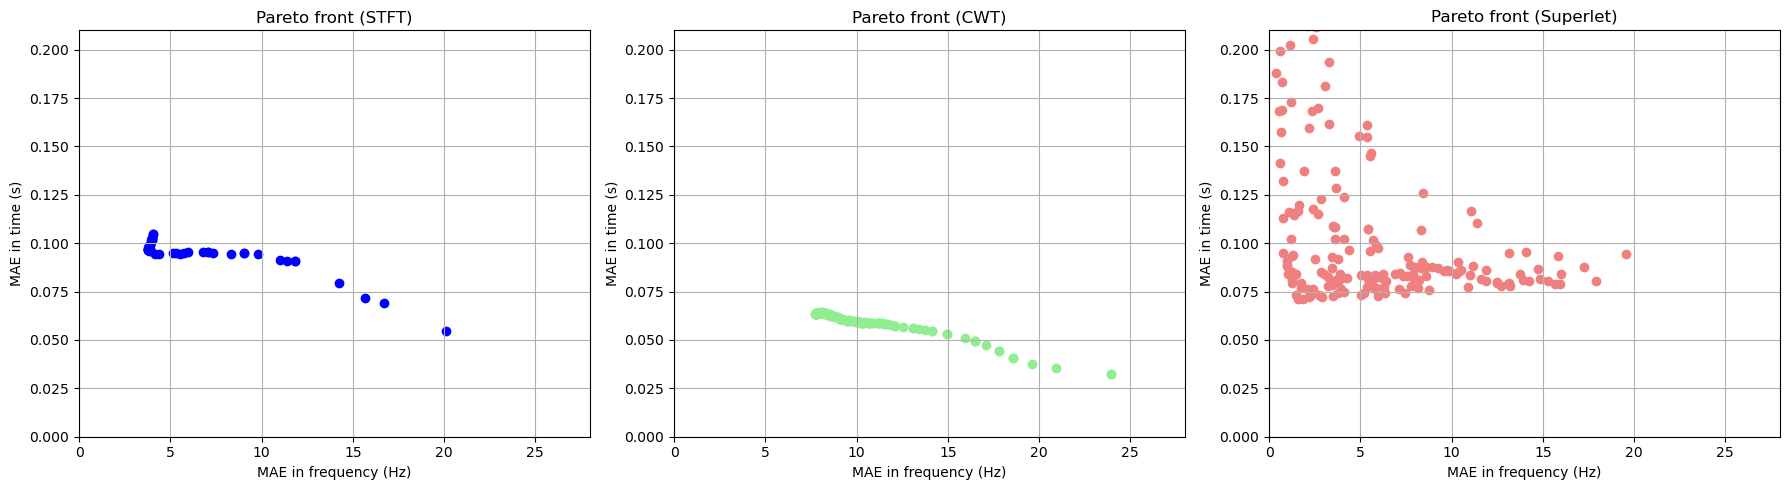

In [41]:
# Calcula los límites a partir de los datos de Superlet
# x_min = min(mae_f_vals_random_superlet)
# x_max = max(mae_f_vals_random_superlet)
# y_min = min(mae_t_vals_random_superlet)
# y_max = max(mae_t_vals_random_superlet)
# 
# # Agrega márgenes
# x_margin = (x_max - x_min) * 0.05
# y_margin = (y_max - y_min) * 0.05
# xlim = (x_min - x_margin, x_max + x_margin)
# ylim = (y_min - y_margin, y_max + y_margin)

# Crear figura con 3 subplots en una fila
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Superlet
axs[0].scatter(mae_f_vals_random_stft, mae_t_vals_random_stft, c='blue')
axs[0].set_title("Pareto front (STFT)")
axs[0].set_xlabel("MAE in frequency (Hz)")
axs[0].set_ylabel("MAE in time (s)")
axs[0].set_xlim(0,28)
axs[0].set_ylim(0,0.21)
axs[0].grid(True)

# Wavelet
axs[1].scatter(mae_f_vals_random_our_cwt, mae_t_vals_random_our_cwt, c='lightgreen')
axs[1].set_title("Pareto front (CWT)")
axs[1].set_xlabel("MAE in frequency (Hz)")
axs[1].set_ylabel("MAE in time (s)")
axs[1].set_xlim(0,28)
axs[1].set_ylim(0,0.21)
axs[1].grid(True)

# STFT
axs[2].scatter(mae_f_vals_random_slt, mae_t_vals_random_slt, c='lightcoral')
axs[2].set_title("Pareto front (Superlet)")
axs[2].set_xlabel("MAE in frequency (Hz)")
axs[2].set_ylabel("MAE in time (s)")
axs[2].set_xlim(0,28)
axs[2].set_ylim(0,0.21)
axs[2].grid(True)

# Ajustar espacio
plt.tight_layout()
plt.show()

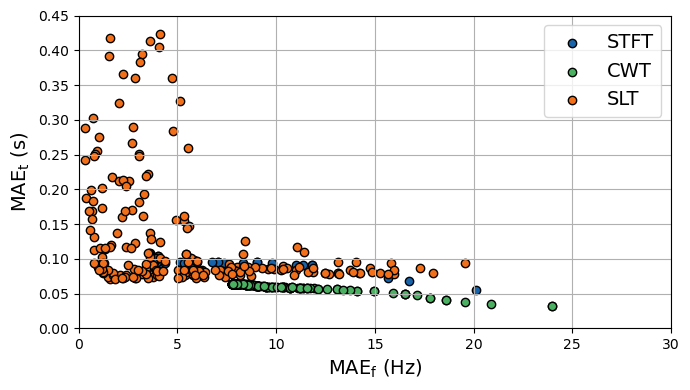

In [45]:
 # Fig tamaño igual al de los subplots (18 x 5)
plt.figure(figsize=(7, 4))

# Misma paleta que definiste
colores_base = {                                 
    "STFT": plt.colormaps["Blues"],              
    "CWT": plt.colormaps["Greens"],          
    "SLT": plt.colormaps["Oranges"],    
}  

# Graficar con los mismos colores y estilo
plt.scatter(mae_f_vals_random_stft,
            mae_t_vals_random_stft, 
            color=colores_base["STFT"](0.8),
            label='STFT',
            edgecolor='black')

plt.scatter(mae_f_vals_random_our_cwt,
            mae_t_vals_random_our_cwt,
            color=colores_base["CWT"](0.6),
            label='CWT',
            edgecolor='black')

plt.scatter(mae_f_vals_random_slt,
            mae_t_vals_random_slt,
            color=colores_base["SLT"](0.6),
            label='SLT',
            edgecolor='black')

# Mismos límites que antes
plt.xlim(0, 30)
plt.ylim(0, 0.45)

# Mismos ejes y estética
plt.xlabel("$\mathregular{MAE_f}$ (Hz)", fontsize=fontsize_labels)
plt.ylabel("$\mathregular{MAE_t}$ (s)", fontsize=fontsize_labels)
plt.xticks(np.arange(0, 31, 5))
plt.yticks(np.arange(0, 0.5, 0.05))

plt.grid(True)
plt.legend(fontsize=fontsize_legend)
plt.tight_layout()

plt.show()


In [ ]:
if plot_tf_representation:
    fig, ax = plt.subplots(ncols=len(params_superlet), figsize=(18,5), dpi=300, sharey=True, sharex=True)
if plot_responses:
    fig_2, (ax_2_1, ax_2_2) = plt.subplots(1, 2, figsize=(18, 5))  
    
mae_superlet_f = []
std_superlet_f = []

mae_superlet_t = []
std_superlet_t = []

for (i, (base_cycle, min_order, max_order)) in enumerate(zip(*params_superlet)):
    print(f'{i+1} parameter')
    out = superlet_new.superlets(signal_5, fs, freqs,base_cycle, [min_order, max_order])
    # New implementation gives the scalogram directly
    scalogram_slt = out
    if plot_tf_representation:
        im = ax[i].imshow(scalogram_slt[mask,:], aspect='auto', cmap=cmc.batlow, interpolation="none", origin="lower",extent=[0, len(signal_5)/fs, freqs[mask][0], freqs[mask][-1]])
        ax[i].set_title(f"$c_1$: {base_cycle}, o: {min_order}-{max_order}", fontsize=fontsize_subtitle)
        ax[i].set_xlabel("Time (s)", fontsize=fontsize_labels)
        if i == 0:
            ax[i].set_ylabel("Frequency (Hz)", fontsize=fontsize_labels)
        else:
            ax[i].set_ylabel("")
        ax[i].set_ylim(f_min, f_max)
        ax[i].grid(False)
   
    # Energy in time is given directly by the scalogram
    first_indices = []
    last_indices = []
    
    # We compute one t_onset and t_offset for each frequency bin in the scalogram (that's why we don´t do energy_t = np.sum(scalogram_cwt, axis=0))

    for row in scalogram_slt:
        first_index, last_index = aux.find_plateau_region(row, burst_start, burst_duration, t, fs, plot_results=False)
        first_indices.append(first_index)
        last_indices.append(last_index)
        
    # last_indices = [i for i in last_indices if i not in (0, 3072)]
    t_onset = t[first_indices]
    t_offset = t[last_indices]
    
    # Compute the instantaneous frequency
    instant_freq = np.sum(scalogram_slt * freqs[:, np.newaxis], axis=0) / np.sum(scalogram_slt, axis=0)
    
    instant_mean_freq_burst = instant_freq[start_idx:end_idx]
    
    if plot_responses:
        ax_2_1.plot(t, instant_freq, label=f"$c_1$: {base_cycle}, o: {min_order}-{max_order}")
        ax_2_1.set_xlabel("Time (s)")
        ax_2_1.set_ylabel("Frequency (Hz)")
        ax_2_1.legend()
        ax_2_1.grid(True)
        ax_2_1.axhline(MNF_1, color='red', linestyle='--')
        ax_2_1.set_title("Instantaneous frequency")
        
        ax_2_2.plot(t,  np.sum(scalogram_slt, axis=0), label=f"c={c}")
        ax_2_2.set_xlabel("Time (s)")
        ax_2_2.set_ylabel("Energy (mV²)")
        ax_2_2.legend()
        ax_2_2.grid(True)
        ax_2_2.axvline(real_t_onset, color='red', linestyle='--')
        ax_2_2.axvline(real_t_offset, color='red', linestyle='--')
        ax_2_2.set_title("Energy over time")
        
    # Compute MAE in frequency
    print(f'Estimated mean frequency: {np.mean(instant_mean_freq_burst)} Hz')
    mae_f, std_f = aux.calculate_mae(instant_mean_freq_burst, MNF_1)
    mae_superlet_f.append(mae_f)
    std_superlet_f.append(std_f)
    
    # Compute MAE in time
    print(f'Estimated onset = {np.mean(t_onset)} s, offset = {np.mean(t_offset)} s')
    mae_t, std_t = aux.calculate_mae((t_onset,t_offset), (real_t_onset,real_t_offset))
    mae_superlet_t.append(mae_t)
    std_superlet_t.append(std_t)
    
        
if plot_tf_representation: 
    cbar = fig.colorbar(pcm, ax=ax, orientation='horizontal', pad=0.12, shrink=0.1)
    
    cbar.set_label('Power (mV²)', rotation=0, labelpad=15, fontsize=fontsize_labels)
        
if save:
    fig.savefig(os.path.join(new_folder_path,f'scalogram_cwt_{SNR}.png'), dpi=300, bbox_inches="tight")
    # fig_2.savefig(os.path.join(new_folder_path,"responses_cwt_5.png"), dpi=300, bbox_inches="tight")
    